In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0117.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0101.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0108.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0110.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0119.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0115.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0116.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0105.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0106.jpeg
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test/Normal/0121.jpeg
/kaggle/input/datase

In [24]:
# Libs for preprocessing  
import numpy as np 
import pandas as pd 
import os 
from PIL import Image
import itertools 
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style("darkgrid")
import warnings 
warnings.filterwarnings("ignore")




In [25]:
# Libs for model 
import time
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.optimizers import Adam , Adamax 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix , classification_report  
 


******Preprocessing******

In [26]:
folder_training = "/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train"
Path = []
Labels = []

#to get the path for each Img :

folders_path = os.listdir(folder_training)
for img in folders_path : 
    FolderPath = os.path.join(folder_training, img)
    FolderName = os.listdir(FolderPath)
    for path in FolderName :
        Images_path = os.path.join(FolderPath, path)
        
        Path.append(Images_path)
        Labels.append(img)

# to creat DataFrame        
Pseries = pd.Series(Path, name = "Img_Path")
Lseries = pd.Series(Labels, name = "Img_label")
df_train = pd.concat([Pseries, Lseries], axis=1)

In [27]:
df_train

,Img_Path,Img_label
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
246,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
247,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
248,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
249,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [28]:
folder_test = "/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test"
Path = []
Labels = []

# To get the path for each image in the test set:

folders_path = os.listdir(folder_test)  # Use folder_test here
for img in folders_path: 
    FolderPath = os.path.join(folder_test, img)  # Use folder_test here
    FolderName = os.listdir(FolderPath)
    for path in FolderName:
        Images_path = os.path.join(FolderPath, path)
        
        Path.append(Images_path)
        Labels.append(img)

# To create DataFrame        
Pseries = pd.Series(Path, name = "Img_Path")
Lseries = pd.Series(Labels, name = "Img_label")
df_test = pd.concat([Pseries, Lseries], axis=1)


In [29]:
df_test

,Img_Path,Img_label
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
61,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
62,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
63,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
64,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [30]:
valid_df, test_df = train_test_split(df_test, train_size=0.5, shuffle= True, random_state=42)

**Data Preparation using ImageDataGenerator**

In [31]:
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_generator = tr_gen.flow_from_dataframe(
    df_train, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

test_generator = ts_gen.flow_from_dataframe(
    test_df, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=batch_size
)

Found 251 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.


**Show Sample of Data**

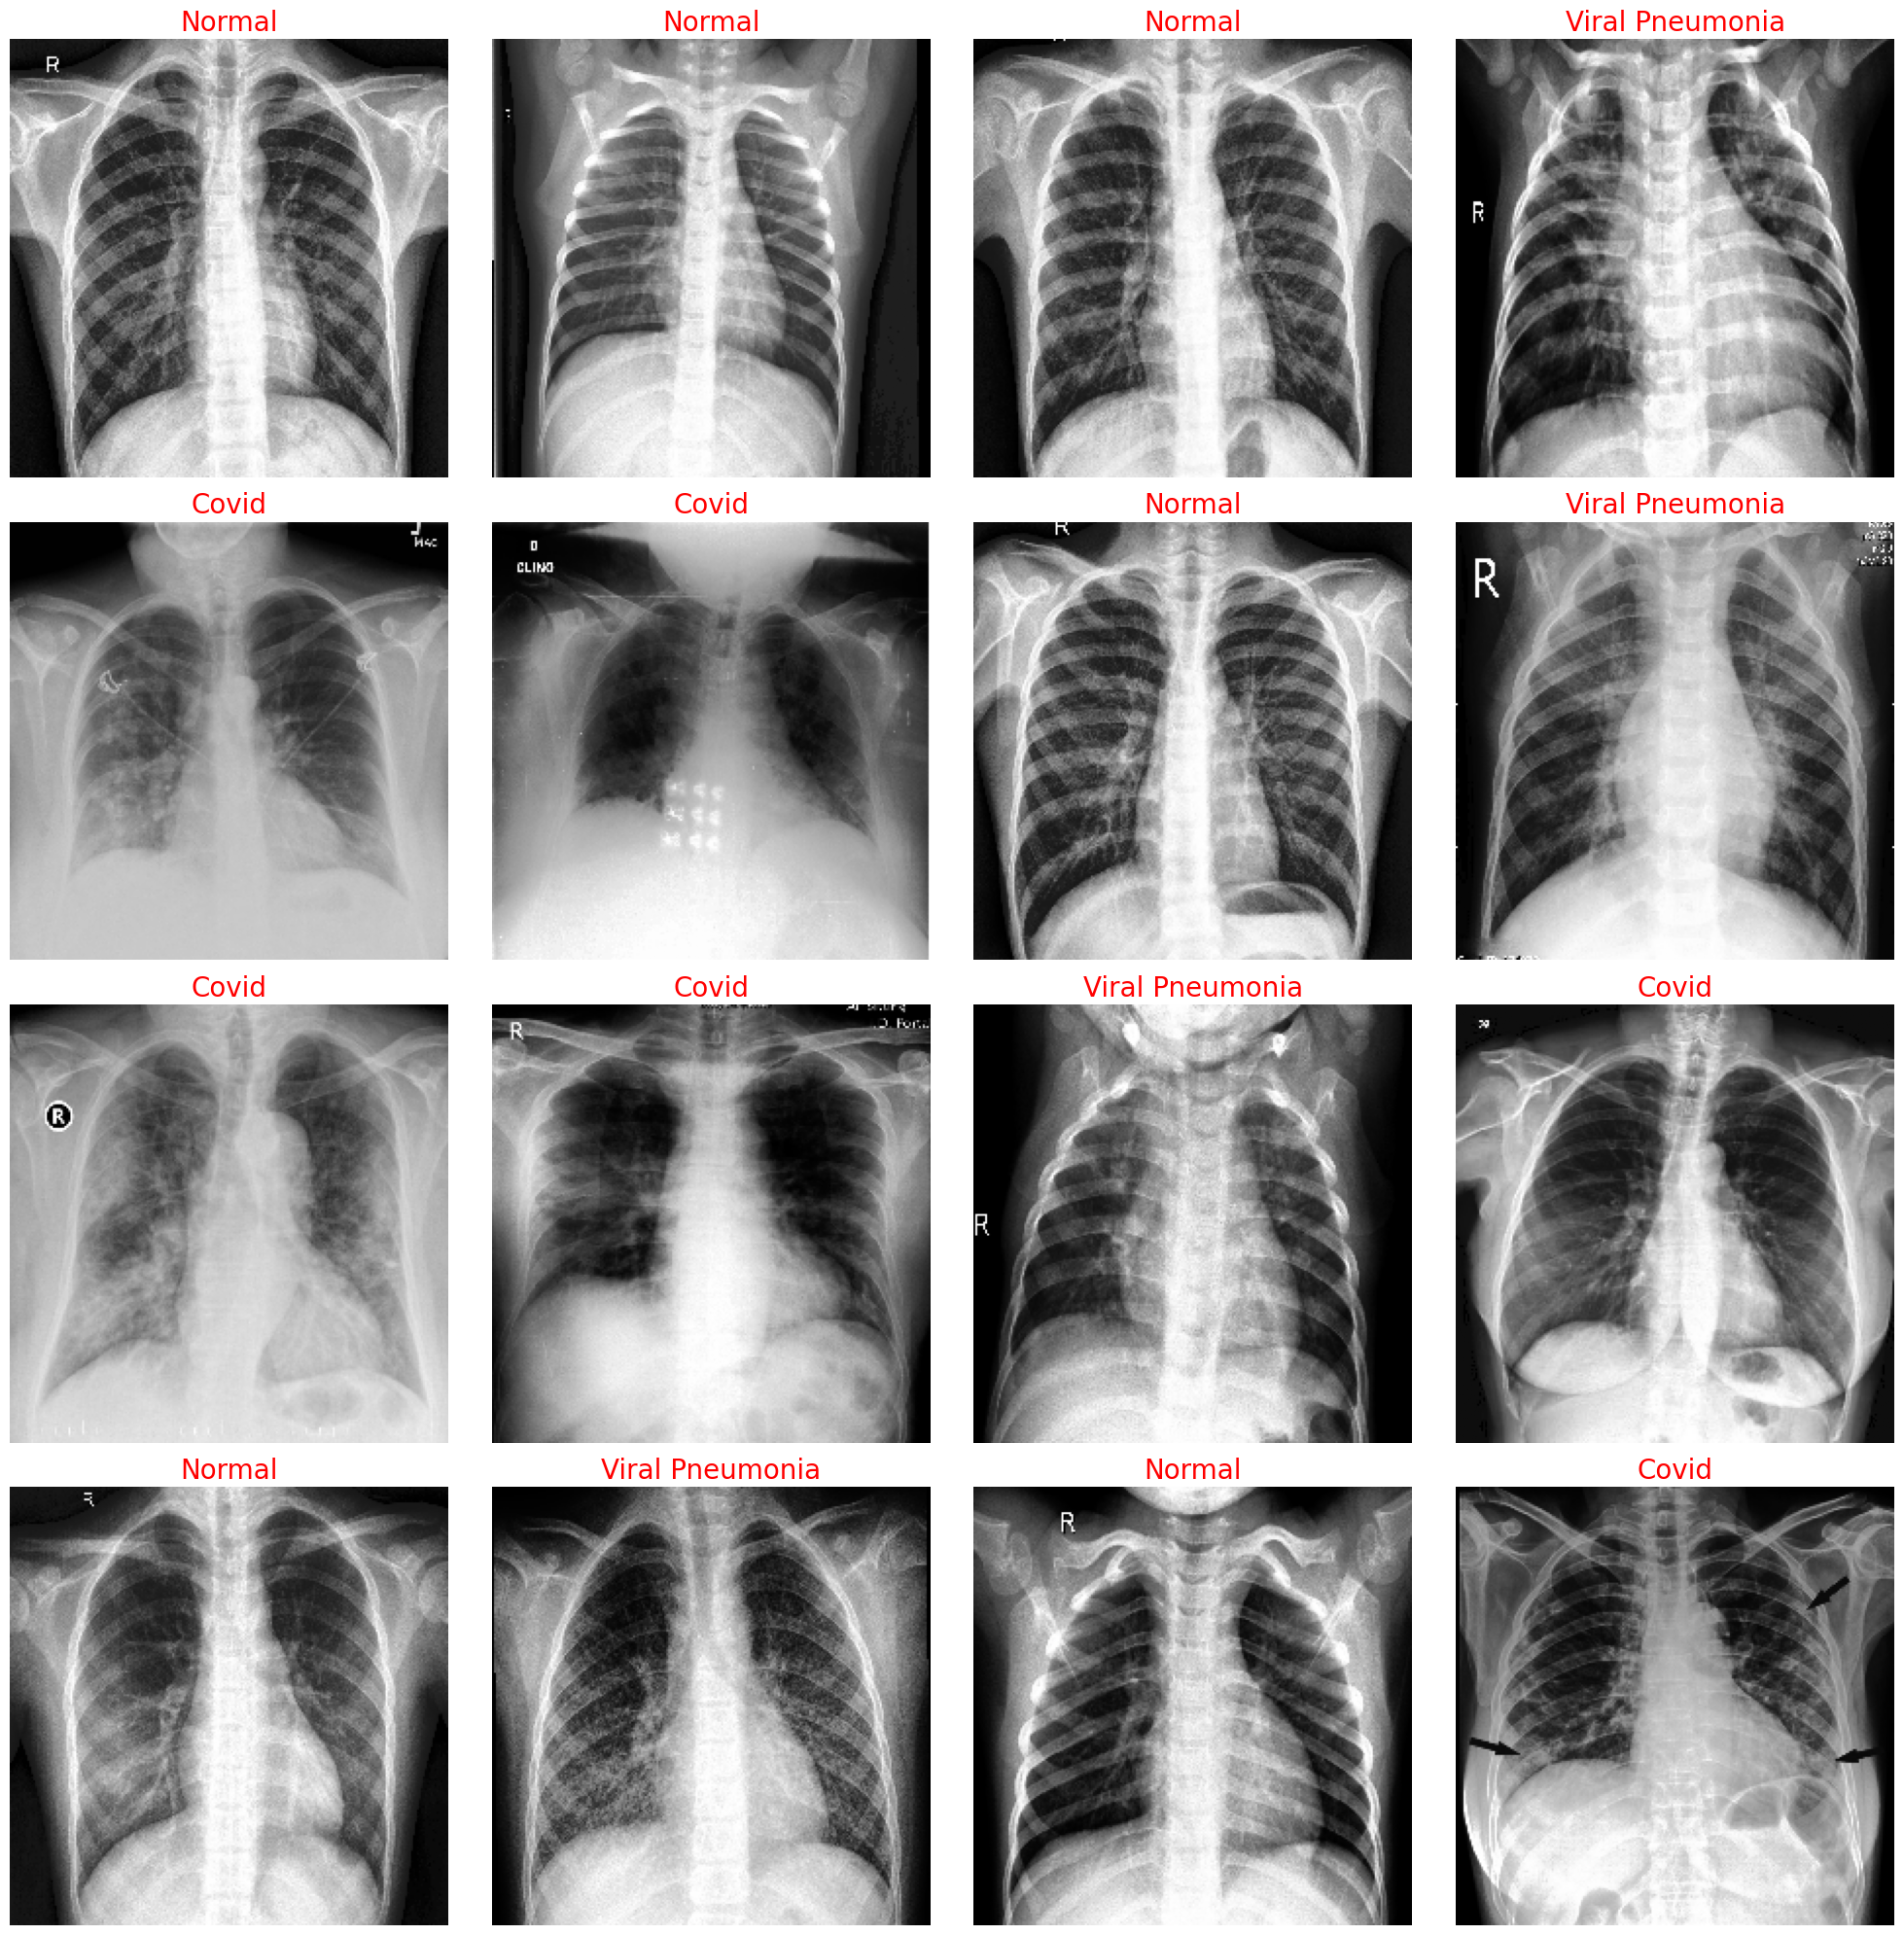

In [32]:
# Dictionary mapping class names to indices
gen_dict = train_generator.class_indices
# List of class names
classes = list(gen_dict.keys())

# Fetch a batch of images and labels
images, labels = next(train_generator)

# Set up the figure size
plt.figure(figsize=(20, 20))

# Loop through the first 20 images in the batch
for i in range(16):
    plt.subplot(4, 4, i + 1)
    
    # Normalize image pixel values to [0, 1] range
    image = images[i] / 255.0
    
    # Display the image
    plt.imshow(image)
    
    # Get the class index and class name
    index = np.argmax(labels[i])  # Get image index
    class_name = classes[index]   # Get class of image
    
    # Set the title with class name
    plt.title(class_name, color='red', fontsize=20)
    plt.axis('off')

# Adjust layout for better spacing between plots
plt.tight_layout()
# Display the plot
plt.show()

**Basic Model using only Conv2D blocks**

In [38]:
NUM_CLASSES = len(train_generator.class_indices)
LEARNING_RATE = 0.001
EPOCHS = 15


In [40]:
def build_basic_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_basic = build_basic_model()
model_basic.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_basic.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Basic Model**

In [42]:
start_time = time.time()

 
history_basic = model_basic.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    verbose=1
)

time_basic = time.time() - start_time


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4422 - loss: 166.0887 - val_accuracy: 0.7879 - val_loss: 0.9609
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 952ms/step - accuracy: 0.8725 - loss: 0.5693 - val_accuracy: 0.7576 - val_loss: 0.5308
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 971ms/step - accuracy: 0.9482 - loss: 0.1299 - val_accuracy: 0.8788 - val_loss: 0.3772
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 921ms/step - accuracy: 0.9721 - loss: 0.0660 - val_accuracy: 0.9394 - val_loss: 0.1593
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 925ms/step - accuracy: 0.9960 - loss: 0.0136 - val_accuracy: 0.9394 - val_loss: 0.1496
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 936ms/step - accuracy: 0.9841 - loss: 0.0455 - val_accuracy: 0.9394 - val_loss: 0.2240
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 924ms/step - accuracy: 0.9960 - loss: 0.0231 - val_accuracy: 0.8788 - val_loss: 0.3361
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 918ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accur

**Regularized Model (BatchNormalization & Dropout)**


In [44]:
def build_regularized_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_reg = build_regularized_model()
model_reg.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_reg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,755 (42.61 MB)

 Trainable params: 11,170,051 (42.61 MB)

 Non-trainable params: 704 (2.75 KB)

**Try Regularized Model**

In [45]:
start_time = time.time()


history_reg = model_reg.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    verbose=1
)

time_reg = time.time() - start_time

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8207 - loss: 0.5722 - val_accuracy: 0.2424 - val_loss: 37.7938
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9283 - loss: 0.1926 - val_accuracy: 0.4848 - val_loss: 15.6416
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9602 - loss: 0.1134 - val_accuracy: 0.5758 - val_loss: 9.3066
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9562 - loss: 0.1244 - val_accuracy: 0.5455 - val_loss: 4.9214
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9801 - loss: 0.0905 - val_accuracy: 0.5758 - val_loss: 2.6079
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9960 - loss: 0.0381 - val_accuracy: 0.6364 - val_loss: 1.7700
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9880 - loss: 0.0427 - val_accuracy: 0.6667 - val_loss: 0.8633
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9960 - loss: 0.0304 - val_accuracy: 0.9091 - val_los

**Metrics Benchmarking & Validation Curves**

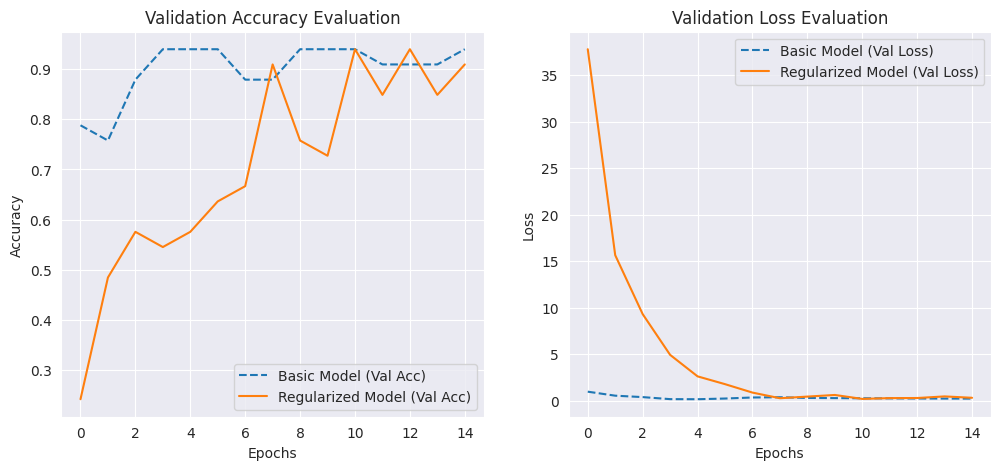

In [46]:

import matplotlib.pyplot as plt

# Extract parameter sizes
params_basic = model_basic.count_params()
params_reg = model_reg.count_params()

# Evaluate test metrics strictly using your test_generator
_, acc_basic = model_basic.evaluate(test_generator, verbose=0)
_, acc_reg = model_reg.evaluate(test_generator, verbose=0)


# Plot training vs validation metric progression
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_basic.history['val_accuracy'], label='Basic Model (Val Acc)', linestyle='--')
plt.plot(history_reg.history['val_accuracy'], label='Regularized Model (Val Acc)', linestyle='-')
plt.title('Validation Accuracy Evaluation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_basic.history['val_loss'], label='Basic Model (Val Loss)', linestyle='--')
plt.plot(history_reg.history['val_loss'], label='Regularized Model (Val Loss)', linestyle='-')
plt.title('Validation Loss Evaluation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**🧠 Operational Resource-Constrained Selection**

Given limited computing hardware, **Model 2 (Regularized CNN)** is the optimal system design for deployment due to the following structural reasons:

* **Parameter and Memory Efficiency:** Incorporating `Dropout` demands zero additional system parameters or disk space. `BatchNormalization` appends a minor scale/shift vector footprint that causes negligible hardware strain during forward evaluation passes.
* **Overfitting Mitigation:** Standard deep architectures trained on high-resolution targets (224x224) memorize samples rather than parsing localized feature attributes. Model 2's dropout rates force the network to develop generalizable intuition, translating to stable validation performance on incoming user data.
* **Early Training Convergence:** The spatial normalization introduced by Batch Normalization dampens chaotic gradient updates, forcing faster early optimization cycles. This operational efficiency means you can safely run fewer total training epochs to achieve reliable clinical diagnostic performance.**

**📊 Final Model Performance Evaluation**

In [47]:
train_score = model_reg.evaluate(train_generator, verbose= 1)
valid_score = model_reg.evaluate(valid_generator, verbose= 1)
test_score = model_reg.evaluate(test_generator, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 460ms/step - accuracy: 0.9960 - loss: 0.0288
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.9091 - loss: 0.3034
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9697 - loss: 0.1265
Train Loss:  0.028822727501392365
Train Accuracy:  0.9960159659385681
--------------------
Validation Loss:  0.30343860387802124
Validation Accuracy:  0.9090909361839294
--------------------
Test Loss:  0.12646667659282684
Test Accuracy:  0.9696969985961914


**🧠 Model Inference & Class Label Extraction**

In [48]:
preds = model_reg.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step


**Confusion matrix for the test datat**

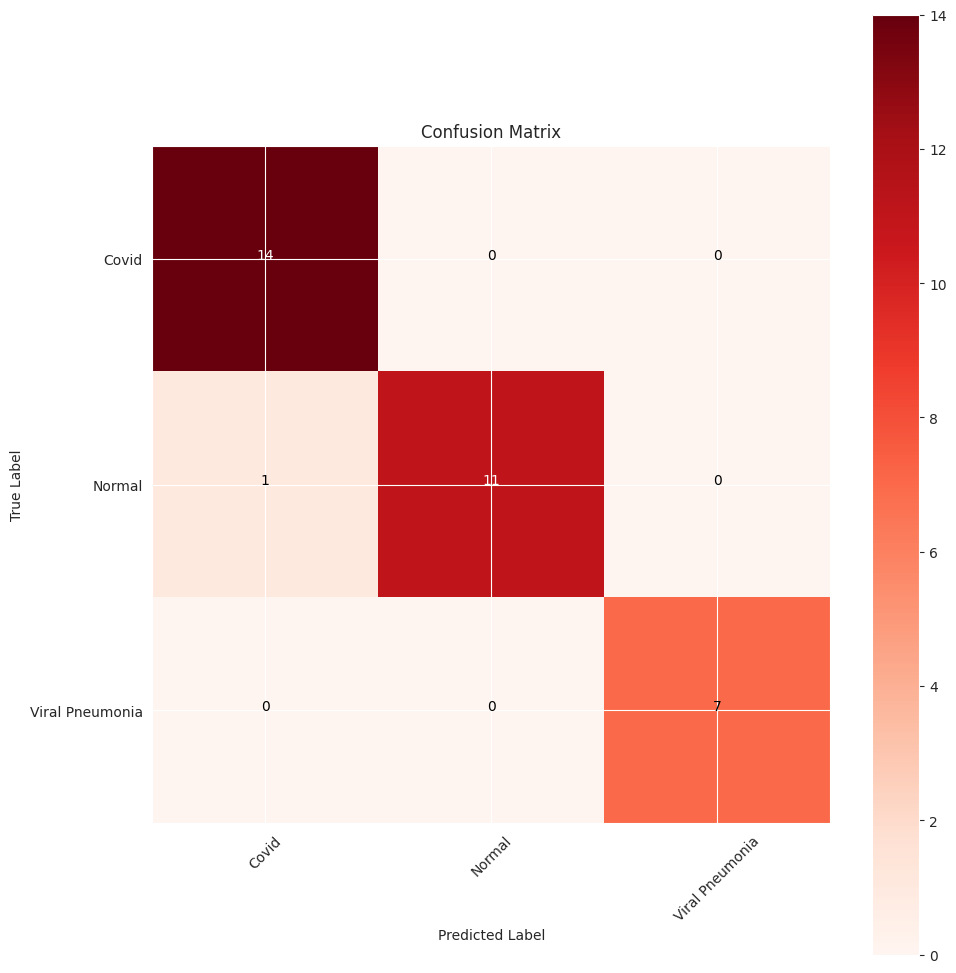

In [49]:
# Generate the class labels
g_dict = test_generator.class_indices
classes = list(g_dict.keys())

# Compute the confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Reds')  # Use red colormap
plt.title('Confusion Matrix')
plt.colorbar()

# Set tick marks and labels
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()  # Adjust subplots to fit into the figure area
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [50]:
print(classification_report(test_generator.classes, y_pred, target_names= classes))

                 precision    recall  f1-score   support

          Covid       0.93      1.00      0.97        14
         Normal       1.00      0.92      0.96        12
Viral Pneumonia       1.00      1.00      1.00         7

       accuracy                           0.97        33
      macro avg       0.98      0.97      0.97        33
   weighted avg       0.97      0.97      0.97        33



**Save Model**

In [52]:
#Save the model
model_reg.save('COVID-19 Classifier.h5')

**Try Model**


In [54]:
# Load the model
loaded_model = tf.keras.models.load_model('/kaggle/working/COVID-19 Classifier.h5', compile=False)
loaded_model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Image path
image_path = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train/Covid/01.jpeg'
image = Image.open(image_path)

# Preprocess the image before prediction
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

# Make predictions
predictions = loaded_model.predict(img_array)
class_labels = ['Covid', 'Normal', 'Viral Pneumonia']

# Print the predicted class
predicted_class = class_labels[np.argmax(predictions)]
print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Covid
